In [1]:
from torch import nn
from torch.nn import functional as F
import torch
from d2l import torch as d2l


In [2]:
#About Modules and Parameter Access
class ParallelModule(nn.Module):
    def __init__(self, net1, net2):
        super().__init__()
        self.net1 = net1
        self.net2 = net2

    def forward(self, X):
        return (self.net1(X), self.net2(X)) 

In [3]:
net1 = nn.Sequential(
    nn.LazyLinear(32),
    nn.ReLU(),
    nn.LazyLinear(16)
)


net2 = nn.Sequential(
    nn.LazyLinear(64),
    nn.ReLU(),
    nn.LazyLinear(16)
)


In [4]:
net = ParallelModule(net1, net2)
X = torch.randn(64, 256)

In [5]:
Y = net(X)
print("Output shape of Y[0] : ", Y[0].shape)
print("Output shape of Y[1] : ", Y[1].shape)

Output shape of Y[0] :  torch.Size([64, 16])
Output shape of Y[1] :  torch.Size([64, 16])


In [6]:
class CustomModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyLinear(32),
            nn.ReLU(),
            nn.LazyLinear(64),
            nn.ReLU(),
            nn.LazyLinear(32),
        )
    def forward(self, X):
        return self.net(X)

In [7]:
class CustomeModel(nn.Module):
    def __init__(self, *args):
        super().__init__()
        for idx, layer in enumerate(args):
            self.add_module(str(idx), layer)
    
    def forward(self, X):
        for layer in self.children():
            X = layer(X)
        return X

In [8]:
def create_model(num_instances=None):
    if num_instances == None:
        raise ValueError("Invalid argument")
    
    layers = []
    for _ in range(num_instances):
        layers.append(CustomModule())

    return CustomeModel(*layers)

In [9]:
net = create_model(3)

In [10]:
X = torch.randn(64, 32)

In [11]:
net(X)

tensor([[ 0.0838, -0.0749,  0.0278,  ...,  0.0367,  0.1796, -0.0822],
        [ 0.0834, -0.0748,  0.0273,  ...,  0.0359,  0.1795, -0.0821],
        [ 0.0836, -0.0750,  0.0278,  ...,  0.0367,  0.1795, -0.0825],
        ...,
        [ 0.0842, -0.0744,  0.0276,  ...,  0.0362,  0.1795, -0.0815],
        [ 0.0835, -0.0742,  0.0268,  ...,  0.0348,  0.1797, -0.0820],
        [ 0.0836, -0.0749,  0.0271,  ...,  0.0357,  0.1794, -0.0821]],
       grad_fn=<AddmmBackward0>)

In [12]:
class NestMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.LazyLinear(out_features=64), nn.ReLU(),
                                 nn.LazyLinear(32), nn.ReLU())
        self.linear = nn.LazyLinear(16)

    def forward(self, X):
        return self.linear(self.net(X))

In [13]:
nestMLP = NestMLP()

In [14]:
nestMLP(X)
nestMLP.net[0].weight.data

tensor([[-0.0549,  0.0480,  0.0302,  ...,  0.1109, -0.0577, -0.0498],
        [-0.0838, -0.1526,  0.1649,  ...,  0.0234,  0.1622, -0.0806],
        [ 0.0449,  0.0151, -0.0843,  ..., -0.0909, -0.0897, -0.0925],
        ...,
        [-0.0220, -0.0090,  0.1568,  ...,  0.0464,  0.0455,  0.0629],
        [-0.0144,  0.0147,  0.0865,  ..., -0.1274, -0.0632,  0.1066],
        [ 0.1435,  0.0572,  0.0592,  ..., -0.1622,  0.0426,  0.0220]])

### Parameter sharing and Parameter Tying
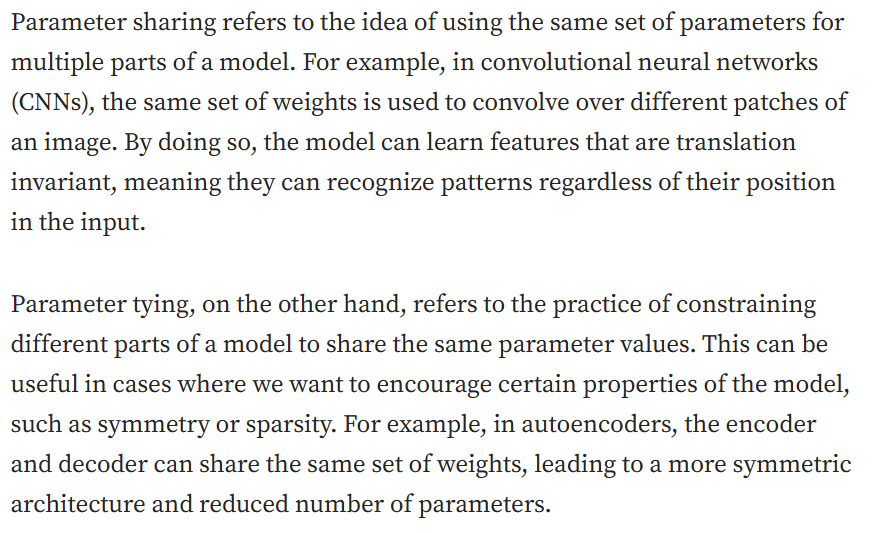

In [15]:
#Custom layers
#Constructing custom layer without parameters

class CenteredLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, X):
        return X - X.mean()


In [16]:
layer = CenteredLayer()
A = torch.rand(3, 4)

In [17]:
layer(A)

tensor([[ 0.0742,  0.1482, -0.0115, -0.1911],
        [-0.1871,  0.3926, -0.2874, -0.2052],
        [ 0.2839, -0.0833, -0.3081,  0.3748]])

In [18]:
#Creating layer with parameters

class CustomLinearLayer(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_inputs, num_outputs))
        self.b = nn.Parameter(torch.randn(num_outputs,))

    def forward(self, X):
        H = torch.matmul(X, self.W.data) + self.b.data
        return F.relu(H)

In [19]:
linear = CustomLinearLayer(4, 2)
A = torch.randn(3, 4)
linear(A)

tensor([[1.7434, 2.4146],
        [0.0000, 0.0000],
        [0.0000, 2.3842]])

In [20]:
class ReductionLayer(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.W = torch.randn(num_inputs, num_inputs, num_outputs)

    def forward(self, X):
        y = torch.einsum('i,j,ijk->k', X, X, self.W)
        return y

In [21]:
red_layer = ReductionLayer(4, 2)
X = torch.randn(4)
red_layer(X)

tensor([ 0.4924, -0.2867])

In [22]:
#Saving and loading tensors

a = torch.arange(0, 4)
torch.save(a, 'a-file')

In [23]:
saved_a = torch.load('a-file')
saved_a

C:\Users\Asus\AppData\Local\Temp\ipykernel_22512\499545088.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_a = torch.load('a-file')


tensor([0, 1, 2, 3])

In [24]:
b = torch.arange(0, 10)
torch.save([a, b], 'multiple-tensors')

In [25]:
x = torch.load('multiple-tensors')
x

C:\Users\Asus\AppData\Local\Temp\ipykernel_22512\365317626.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load('multiple-tensors')


[tensor([0, 1, 2, 3]), tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]

In [26]:
#Saving model's parameters
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.LazyLinear(256)
        self.output = nn.LazyLinear(10)

    def forward(self, x):
        return self.output(F.relu(self.hidden(x)))

net = MLP()
X = torch.randn(size=(2, 20))
Y = net(X)

In [27]:
torch.save(net.state_dict(), 'mlp.parameters')

In [28]:
clone = MLP()
clone.load_state_dict(torch.load('mlp.parameters'))

C:\Users\Asus\AppData\Local\Temp\ipykernel_22512\3330266570.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clone.load_state_dict(torch.load('mlp.parameters'))


<All keys matched successfully>

In [29]:
#Results of original MLP and cloned MLP are same as same parameter values of original MLP are used in cloned MLP 
clone(X) == Y

tensor([[True, True, True, True, True, True, True, True, True, True],
        [True, True, True, True, True, True, True, True, True, True]])

In [47]:
class MLPWithDynamicLayers(nn.Module):
    def __init__(self, num_layers, hidden_units, num_outputs):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(num_layers):
            self.net.add_module(f"hidden_layer_{i}", nn.LazyLinear(hidden_units))
            self.net.add_module(f"act_hidden_layer_{i}", nn.ReLU())
        self.net.add_module("output_layer", nn.LazyLinear(num_outputs))

    def forward(self, X):
        return self.net(X)

In [48]:
X = torch.randn(size=(4, 3))
X

tensor([[-0.7688, -0.8510,  1.2599],
        [-0.2142, -0.8620,  0.4726],
        [ 0.0379,  0.2276,  1.1412],
        [-0.7130,  0.1741, -1.0497]])

In [53]:
MLPWith2Layers = MLPWithDynamicLayers(2, 128, 2)

In [54]:
MLPWith2Layers(X)

tensor([[-0.1481,  0.0206],
        [-0.1070,  0.0049],
        [ 0.0172, -0.0245],
        [-0.0321, -0.1507]], grad_fn=<AddmmBackward0>)

In [55]:
torch.save(MLPWith2Layers.state_dict(), "mlp.two-layers")

In [56]:
params = torch.load("mlp.two-layers")

C:\Users\Asus\AppData\Local\Temp\ipykernel_22512\3644417397.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  params = torch.load("mlp.two-layers")


In [66]:
MLPWith3Layers = MLPWithDynamicLayers(3, 128, 3)

In [70]:
#Loading parameters of first 2 layers of MPLWith2Layers inside first 2 layers of MLPWith3Layers
MLPWith3Layers.load_state_dict(params, strict=False)

_IncompatibleKeys(missing_keys=['net.hidden_layer_2.weight', 'net.hidden_layer_2.bias'], unexpected_keys=[])